# 02 — EDA Comportamental: Análise do Histórico de Pedidos

Este notebook analisa os dados comportamentais dos clientes da Praso —
especificamente o histórico de pedidos e atrasos de pagamento. O objetivo
é entender os padrões de comportamento de compra e construir features
agregadas por cliente que alimentarão o Modelo Comportamental.

**Input:** `pedidos.csv`  
**Output:** insights sobre comportamento de compra + features agregadas prontas
para o merge com o dataset de aplicação

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Carregamento
df_pedidos = pd.read_csv('/content/drive/MyDrive/ML_Inadimplencia_Praso/data/comportamental.csv')
df_app     = pd.read_csv('/content/drive/MyDrive/ML_Inadimplencia_Praso/data/aplicacao.csv')

print(f"Pedidos — shape: {df_pedidos.shape}")
print(f"Aplicação — shape: {df_app.shape}")
print()
print("Primeiras linhas:")
df_pedidos.head(10)

Pedidos — shape: (1977, 5)
Aplicação — shape: (3000, 19)

Primeiras linhas:


,id_pedido,id_cliente,valor,atraso,data_entrega
0,1001467582914,1377618222119,"(0, 500]","(0, 2]",2023-07-29
1,1002041733861,7615097701411,"(0, 500]","(0, 2]",2023-08-08
2,1007388416391,3203166621981,"(0, 500]","(-100, 0]",2023-11-28
3,1010723925871,3469531155445,"(0, 500]","(0, 2]",2023-10-11
4,1014450723619,6488389293138,"(500, 1000]","(2, 4]",2023-12-08
5,1014983632314,2918438151968,"(0, 500]","(4, 6]",2024-04-30
6,1021642359839,2946361534283,"(0, 500]","(0, 2]",2025-12-29
7,1053518854751,2918438151968,"(0, 500]","(0, 2]",2024-03-18
8,1056993226169,1003899664289,"(0, 500]","(6, 10]",2023-05-22
9,1061153331621,4432717900919,"(500, 1000]","(0, 2]",2023-04-05


## Seção 1 — Definição do Problema Comportamental

### 1.1 — Contexto

O Modelo de Aplicação avalia o risco de inadimplência de um cliente **no
momento do cadastro**, usando apenas informações disponíveis antes da primeira
compra (dados públicos da Receita Federal, Serasa, iFood, Google Maps).

O Modelo Comportamental vai além: ele avalia o risco de um cliente **ativo**
— que já fez pelo menos uma compra — incorporando o seu histórico de pedidos
e pagamentos na Praso. A premissa é que o comportamento passado de um cliente
dentro da plataforma é um sinal muito mais direto de risco do que dados
cadastrais externos.

### 1.2 — O que este modelo responde

> *"Dado que este cliente já comprou na Praso, qual a probabilidade de ele
> ficar inadimplente no próximo pedido?"*

As features disponíveis para este modelo são:
- Todas as variáveis do modelo de aplicação (dados cadastrais)
- **Mais:** variáveis agregadas construídas a partir do histórico de pedidos:
  frequência de compra, valor médio, padrão de atraso, tendência recente etc.

### 1.3 — Variável Target

A variável target continua sendo `inadimplente` (0 ou 1), presente no dataset
de aplicação e vinculada ao cliente via `id_cliente`.

### 1.4 — Cuidados com Data Leakage

Este é o principal risco técnico do modelo comportamental. A variável `atraso`
registra quantos dias o cliente atrasou para pagar um pedido — mas um pedido
só é marcado como atrasado **após** o vencimento. Portanto:

- Pedidos futuros ao evento de inadimplência **não podem ser usados** como
  features, pois não estariam disponíveis no momento da decisão de crédito.
- Na prática, devemos usar apenas pedidos anteriores a uma data de corte
  definida pelo negócio (ex: últimos 30 dias de atividade do cliente).
- Para este projeto, consideraremos que todos os pedidos disponíveis no
  dataset são **anteriores** ao evento de inadimplência, dado que os dados
  já foram pré-filtrados pela Praso com esse critério.


## Seção 2 — Saúde dos Dados


In [ ]:
# 2.1 — Tipos e missing values
print("=== DTYPES ===")
print(df_pedidos.dtypes)
print()

print("=== MISSING VALUES ===")
missing = df_pedidos.isnull().sum()
missing_pct = (missing / len(df_pedidos) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct': missing_pct}))
print()

# 2.2 — Duplicatas
dup_pedidos = df_pedidos['id_pedido'].duplicated().sum()
print(f"Pedidos duplicados (id_pedido): {dup_pedidos}")
print()

# 2.3 — Clientes únicos no comportamental
clientes_comportamental = df_pedidos['id_cliente'].nunique()
clientes_aplicacao = df_app['id_cliente'].nunique()
print(f"Clientes únicos em pedidos:   {clientes_comportamental}")
print(f"Clientes únicos em aplicação: {clientes_aplicacao}")
print()

# 2.4 — Cobertura: quais clientes do aplicação têm pedidos?
ids_com_pedido = set(df_pedidos['id_cliente'].unique())
ids_aplicacao  = set(df_app['id_cliente'].unique())

so_aplicacao      = ids_aplicacao - ids_com_pedido   # cadastrados mas sem pedido
so_comportamental = ids_com_pedido - ids_aplicacao   # pedidos sem cadastro

print(f"Clientes com cadastro mas SEM pedido:  {len(so_aplicacao)}")
print(f"Clientes com pedido mas SEM cadastro:  {len(so_comportamental)}")
print(f"Clientes com cadastro E com pedido:    {len(ids_aplicacao & ids_com_pedido)}")
print()

# 2.5 — Distribuição de pedidos por cliente
pedidos_por_cliente = df_pedidos.groupby('id_cliente')['id_pedido'].count()
print("=== PEDIDOS POR CLIENTE ===")
print(pedidos_por_cliente.describe().round(2))
print()
print(f"Clientes com apenas 1 pedido:  {(pedidos_por_cliente == 1).sum()}")
print(f"Clientes com 2-5 pedidos:      {((pedidos_por_cliente >= 2) & (pedidos_por_cliente <= 5)).sum()}")
print(f"Clientes com mais de 5 pedidos:{(pedidos_por_cliente > 5).sum()}")

=== DTYPES ===
id_pedido        int64
id_cliente       int64
valor           object
atraso          object
data_entrega    object
dtype: object

=== MISSING VALUES ===
              count   pct
id_pedido         0  0.00
id_cliente        0  0.00
valor             1  0.05
atraso            1  0.05
data_entrega      0  0.00

Pedidos duplicados (id_pedido): 0

Clientes únicos em pedidos:   664
Clientes únicos em aplicação: 3000

Clientes com cadastro mas SEM pedido:  2336
Clientes com pedido mas SEM cadastro:  0
Clientes com cadastro E com pedido:    664

=== PEDIDOS POR CLIENTE ===
count    664.00
mean       2.98
std        0.17
min        1.00
25%        3.00
50%        3.00
75%        3.00
max        3.00
Name: id_pedido, dtype: float64

Clientes com apenas 1 pedido:  2
Clientes com 2-5 pedidos:      662
Clientes com mais de 5 pedidos:0


In [ ]:
# 2.6 — Investigar o missing
print("=== LINHA COM MISSING ===")
print(df_pedidos[df_pedidos['valor'].isnull() | df_pedidos['atraso'].isnull()])
print()

# 2.7 — Categorias únicas de valor e atraso (para planejar o ponto médio)
print("=== CATEGORIAS DE VALOR ===")
print(sorted(df_pedidos['valor'].dropna().unique()))
print()

print("=== CATEGORIAS DE ATRASO ===")
print(sorted(df_pedidos['atraso'].dropna().unique()))
print()

# 2.8 — Range temporal dos pedidos
df_pedidos['data_entrega'] = pd.to_datetime(df_pedidos['data_entrega'])
print("=== RANGE TEMPORAL ===")
print(f"Pedido mais antigo: {df_pedidos['data_entrega'].min().date()}")
print(f"Pedido mais recente: {df_pedidos['data_entrega'].max().date()}")
print(f"Período coberto: {(df_pedidos['data_entrega'].max() - df_pedidos['data_entrega'].min()).days} dias")

=== LINHA COM MISSING ===
          id_pedido     id_cliente        valor     atraso data_entrega
1445  7398361740871  5994079667695  (500, 1000]        NaN   2022-08-29
1875  9524457624797  2153739688514          NaN  (-100, 0]   2024-07-12

=== CATEGORIAS DE VALOR ===
['(0, 500]', '(1000, 2000]', '(2000, 10000000]', '(500, 1000]']

=== CATEGORIAS DE ATRASO ===
['(-100, 0]', '(0, 2]', '(10, 15]', '(15, 30]', '(2, 4]', '(30, 60]', '(4, 6]', '(6, 10]', '(60, 10000000]']

=== RANGE TEMPORAL ===
Pedido mais antigo: 2022-04-25
Pedido mais recente: 2026-04-01
Período coberto: 1437 dias


### Interpretação

### 2.1 — Visão Geral

| Atributo | Valor |
|---|---|
| Total de pedidos | 1.977 |
| Total de clientes únicos | 664 |
| Clientes da aplicação com pedidos | 664 (22,1%) |
| Clientes da aplicação sem pedidos | 2.336 (77,9%) |
| Pedidos duplicados | 0 |

O dataset comportamental cobre apenas **22,1% da base de cadastro**, o que
é esperado — nem todo cliente que se cadastra na Praso realiza compras. O
modelo comportamental, portanto, será treinado e aplicado exclusivamente
sobre esse subconjunto de clientes ativos.

Nenhum pedido pertence a um cliente fora do cadastro, garantindo integridade
referencial entre as duas tabelas.

### 2.2 — Distribuição de Pedidos por Cliente

| Estatística | Valor |
|---|---|
| Média | 2,98 pedidos |
| Mediana | 3 pedidos |
| Mínimo | 1 pedido |
| Máximo | 3 pedidos |
| Clientes com 1 pedido | 2 |
| Clientes com 2–5 pedidos | 662 |

A distribuição é notavelmente concentrada: **praticamente todos os clientes
possuem exatamente 3 pedidos**, com desvio padrão de apenas 0,17. Isso indica
que o dataset foi exportado com um corte de até 3 pedidos por cliente,
provavelmente os 3 mais recentes. Essa estrutura tem impacto direto nas
features que poderemos construir — métricas como "tendência de atraso" e
"frequência mensal" terão baixa variância entre clientes.

### 2.3 — Tipos das Variáveis

| Coluna | Tipo Raw | Observação |
|---|---|---|
| `id_pedido` | int64 | Identificador único |
| `id_cliente` | int64 | Chave para JOIN com aplicação |
| `valor` | object | Intervalos categóricos — requer conversão para ponto médio |
| `atraso` | object | Intervalos categóricos — requer conversão para ponto médio |
| `data_entrega` | object | String de data — converter para datetime |

Assim como observado no dataset de aplicação, as variáveis `valor` e `atraso`
foram anonimizadas em intervalos para proteção dos dados. Ambas precisarão
de tratamento para extração do ponto médio antes da agregação por cliente.

### 2.4 — Missing Values

| Coluna | Missing | % |
|---|---|---|
| `id_pedido` | 0 | 0,00% |
| `id_cliente` | 0 | 0,00% |
| `valor` | 1 | 0,05% |
| `atraso` | 1 | 0,05% |
| `data_entrega` | 0 | 0,00% |

Foram identificados **2 registros com missing** — em linhas e clientes
distintos: um pedido sem `atraso` registrado e outro sem `valor`. Por se
tratar de volume irrisório (0,05% cada) e por não ser possível imputar
esses valores com segurança, ambos os registros serão removidos.

### 2.5 — Cobertura Temporal

| Atributo | Valor |
|---|---|
| Pedido mais antigo | 2022-04-25 |
| Pedido mais recente | 2026-04-01 |
| Período coberto | 1.437 dias (~4 anos) |

O dataset cobre aproximadamente **4 anos de operação** da Praso, desde o
início das atividades até o período mais recente. Essa amplitude temporal
é relevante para análises de sazonalidade e tendência, mas deve ser
considerada com cautela na agregação por cliente — um cliente com pedidos
em 2022 e outro com pedidos em 2025 podem estar em contextos operacionais
distintos.

## Seção 3 — Análise da Variável `atraso`

A variável `atraso` representa o número de dias que o cliente demorou para
pagar um pedido além do prazo acordado. É a variável mais estratégica deste
dataset — um proxy direto do comportamento de pagamento do cliente e,
consequentemente, do risco de inadimplência.

Antes de qualquer agregação por cliente, é essencial entender a distribuição
bruta do atraso a nível de pedido: qual a proporção de pedidos sem atraso,
onde se concentram os atrasos, e como se comporta a cauda de atrasos graves.

Pedidos após remoção de missings: 1975

=== VERIFICAÇÃO DA CONVERSÃO DE ATRASO ===
atraso
(-100, 0]          0.0
(0, 2]             1.0
(2, 4]             3.0
(4, 6]             5.0
(6, 10]            8.0
(10, 15]          12.5
(15, 30]          22.5
(30, 60]          45.0
(60, 10000000]    60.0
Name: atraso_num, dtype: float64

=== ESTATÍSTICAS DE atraso_num ===
count    1975.00
mean        2.71
std         6.83
min         0.00
25%         0.00
50%         1.00
75%         3.00
max        60.00
Name: atraso_num, dtype: float64

=== DISTRIBUIÇÃO POR FAIXA DE RISCO ===
                     count   pct
faixa_risco_atraso              
0 — No prazo           542  27.4
1 — Leve (1-2d)        903  45.7
2 — Moderado (3-6d)    360  18.2
3 — Alto (7-15d)       114   5.8
4 — Grave (>15d)        56   2.8


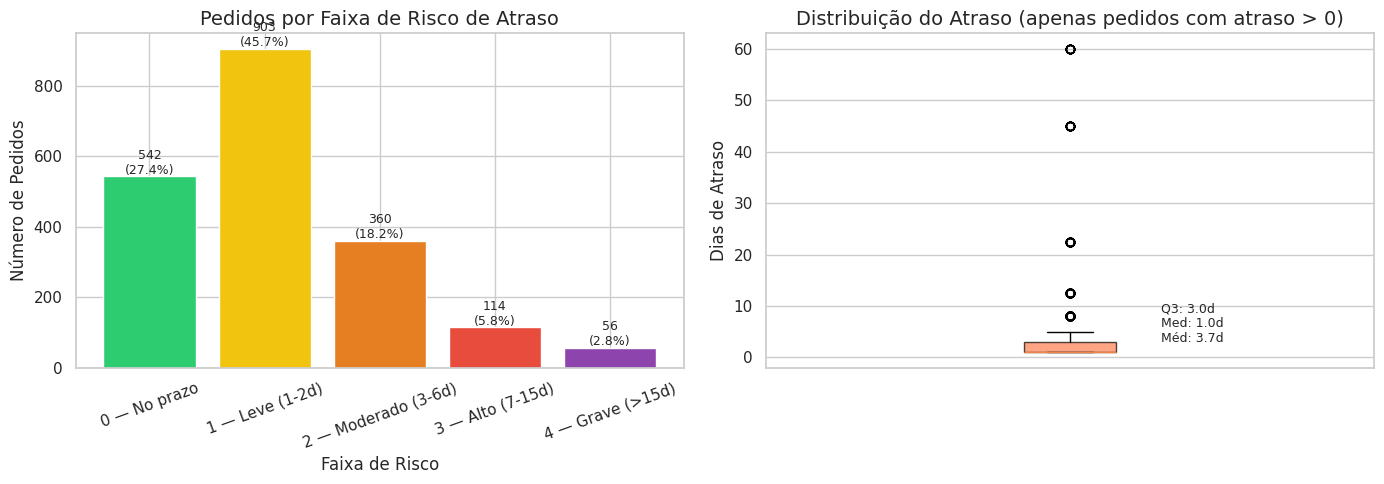


Pedidos no prazo (atraso = 0):   542 (27.4%)
Pedidos com atraso leve (1-2d):  903 (45.7%)
Pedidos com atraso grave (>15d): 56 (2.8%)


In [ ]:
# Seção 3 — Análise da Variável atraso
# 3.1 — Conversão para ponto médio
# Lógica especial:
#   (-100, 0] → 0   (pagou no prazo ou antecipado — sem atraso)
#   (60, 10000000] → 60  (catch-all de atrasos muito graves — usamos o piso)

def intervalo_para_ponto_medio(valor_str, col='atraso'):
    """
    Converte string de intervalo '(a, b]' para ponto médio numérico.
    Tratamentos especiais para catch-alls de atraso e valor.
    """
    if pd.isna(valor_str):
        return np.nan
    try:
        a, b = valor_str.strip('()[]').split(',')
        a, b = float(a.strip()), float(b.strip())

        if col == 'atraso':
            if a < 0:   return 0      # (-100, 0] → sem atraso real
            if b >= 1e6: return 60    # (60, 10000000] → piso conservador
        if col == 'valor':
            if b >= 1e6: return 2000  # (2000, 10000000] → piso da faixa

        return (a + b) / 2
    except:
        return np.nan

# Remover missings antes de converter
df_pedidos = df_pedidos.dropna(subset=['valor', 'atraso']).copy()
print(f"Pedidos após remoção de missings: {len(df_pedidos)}")

df_pedidos['atraso_num'] = df_pedidos['atraso'].apply(
    lambda x: intervalo_para_ponto_medio(x, col='atraso')
)
df_pedidos['valor_num'] = df_pedidos['valor'].apply(
    lambda x: intervalo_para_ponto_medio(x, col='valor')
)

print("\n=== VERIFICAÇÃO DA CONVERSÃO DE ATRASO ===")
print(df_pedidos.groupby('atraso')['atraso_num'].first().sort_values())

# 3.2 — Estatísticas descritivas do atraso numérico
print("\n=== ESTATÍSTICAS DE atraso_num ===")
print(df_pedidos['atraso_num'].describe().round(2))

# 3.3 — Categorização do atraso em faixas de risco
def classificar_atraso(dias):
    if dias == 0:    return '0 — No prazo'
    elif dias <= 2:  return '1 — Leve (1-2d)'
    elif dias <= 6:  return '2 — Moderado (3-6d)'
    elif dias <= 15: return '3 — Alto (7-15d)'
    else:            return '4 — Grave (>15d)'

df_pedidos['faixa_risco_atraso'] = df_pedidos['atraso_num'].apply(classificar_atraso)

print("\n=== DISTRIBUIÇÃO POR FAIXA DE RISCO ===")
ordem_risco = ['0 — No prazo', '1 — Leve (1-2d)', '2 — Moderado (3-6d)',
               '3 — Alto (7-15d)', '4 — Grave (>15d)']
dist_risco = df_pedidos['faixa_risco_atraso'].value_counts().reindex(ordem_risco)
dist_risco_pct = (dist_risco / len(df_pedidos) * 100).round(1)
print(pd.DataFrame({'count': dist_risco, 'pct': dist_risco_pct}))

# 3.4 — Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Distribuição por faixa de risco
cores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
axes[0].bar(dist_risco.index, dist_risco.values, color=cores, edgecolor='white')
axes[0].set_title('Pedidos por Faixa de Risco de Atraso')
axes[0].set_xlabel('Faixa de Risco')
axes[0].set_ylabel('Número de Pedidos')
axes[0].tick_params(axis='x', rotation=20)
for i, (v, p) in enumerate(zip(dist_risco.values, dist_risco_pct.values)):
    axes[0].text(i, v + 8, f'{v}\n({p}%)', ha='center', fontsize=9)

# Gráfico 2 — Boxplot do atraso numérico (excluindo zeros para visualizar a cauda)
atraso_positivo = df_pedidos[df_pedidos['atraso_num'] > 0]['atraso_num']
axes[1].boxplot(atraso_positivo, vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[1].set_title('Distribuição do Atraso (apenas pedidos com atraso > 0)')
axes[1].set_ylabel('Dias de Atraso')
axes[1].set_xticks([])
stats_atraso = atraso_positivo.describe()
axes[1].text(1.15, stats_atraso['75%'],
             f"Q3: {stats_atraso['75%']:.1f}d\nMed: {stats_atraso['50%']:.1f}d\nMéd: {stats_atraso['mean']:.1f}d",
             fontsize=9)
plt.tight_layout()
plt.show()

# 3.5 — Proporção geral
print(f"\nPedidos no prazo (atraso = 0):   {(df_pedidos['atraso_num'] == 0).sum()} "
      f"({(df_pedidos['atraso_num'] == 0).mean()*100:.1f}%)")
print(f"Pedidos com atraso leve (1-2d):  {((df_pedidos['atraso_num'] > 0) & (df_pedidos['atraso_num'] <= 2)).sum()} "
      f"({((df_pedidos['atraso_num'] > 0) & (df_pedidos['atraso_num'] <= 2)).mean()*100:.1f}%)")
print(f"Pedidos com atraso grave (>15d): {(df_pedidos['atraso_num'] > 15).sum()} "
      f"({(df_pedidos['atraso_num'] > 15).mean()*100:.1f}%)")

### Interpretação

### 3.1 — Conversão para Ponto Médio

A variável `atraso` foi anonimizada em intervalos categóricos. Para viabilizar
a agregação por cliente, cada intervalo foi convertido para seu ponto médio
numérico, com dois tratamentos especiais:

- `(-100, 0]` → **0**: indica pagamento no prazo ou antecipado. O valor
  negativo não representa atraso real — é um artefato do intervalo.
- `(60, 10000000]` → **60**: catch-all para atrasos muito graves. Usamos o
  piso da faixa como valor conservador, evitando distorção da média por um
  limite superior artificial de 10 milhões.

Após a remoção dos 2 registros com missing (0,10% da base), o dataset
comportamental ficou com **1.975 pedidos**.

### 3.2 — Distribuição do Atraso

| Faixa de Risco | Pedidos | % |
|---|---|---|
| No prazo (0 dias) | 542 | 27,4% |
| Leve (1–2 dias) | 903 | 45,7% |
| Moderado (3–6 dias) | 360 | 18,2% |
| Alto (7–15 dias) | 114 | 5,8% |
| Grave (> 15 dias) | 56 | 2,8% |

### 3.3 — Interpretação

**Atraso de 1–2 dias é o comportamento padrão na Praso.** Com mediana de
1 dia e Q3 de 3 dias entre os pedidos que atrasaram, a grande maioria dos
atrasos são de curtíssima duração — provavelmente reflexo de variações
operacionais como fins de semana, feriados e processamento bancário, e não
de dificuldades financeiras reais do cliente.

Isso é confirmado pelo boxplot: a caixa interquartil é extremamente achatada
(IQR de apenas 2 dias), enquanto os outliers chegam a 22, 45 e 60 dias —
indicando uma cauda longa de casos verdadeiramente problemáticos.

**Implicações para a modelagem:**
- Tratar atraso de 1–2 dias como equivalente a "no prazo" pode ser uma
  decisão válida do ponto de vista de negócio.
- A fronteira real de risco parece começar a partir de **7 dias de atraso**,
  onde a inadimplência provavelmente se concentra.
- Features como `atraso_maximo` e `proporcao_pedidos_graves` (atraso > 7d)
  devem ter maior poder preditivo do que o atraso médio bruto.
- A média de 2,71 dias com desvio padrão de 6,83 confirma a assimetria
  extrema da distribuição — a média é puxada pela cauda e não representa
  bem o comportamento típico. A **mediana será preferida** nas agregações.

## Seção 4 — Análise da Variável `valor`

A variável `valor` representa o montante das mercadorias pedidas pelo cliente,
excluindo cupons de desconto. Diferentemente do `atraso`, que é um sinal
direto de comportamento de pagamento, o valor do pedido é um indicador do
perfil de consumo do cliente — ticket médio, capacidade de compra e
potencial exposição financeira da Praso em caso de inadimplência.

=== ESTATÍSTICAS DE valor_num ===
count    1975.00
mean      402.78
std       354.60
min       250.00
25%       250.00
50%       250.00
75%       250.00
max      2000.00
Name: valor_num, dtype: float64

=== DISTRIBUIÇÃO POR FAIXA DE VALOR ===
                  count   pct
valor                        
(0, 500]           1577  79.8
(500, 1000]         277  14.0
(1000, 2000]         97   4.9
(2000, 10000000]     24   1.2


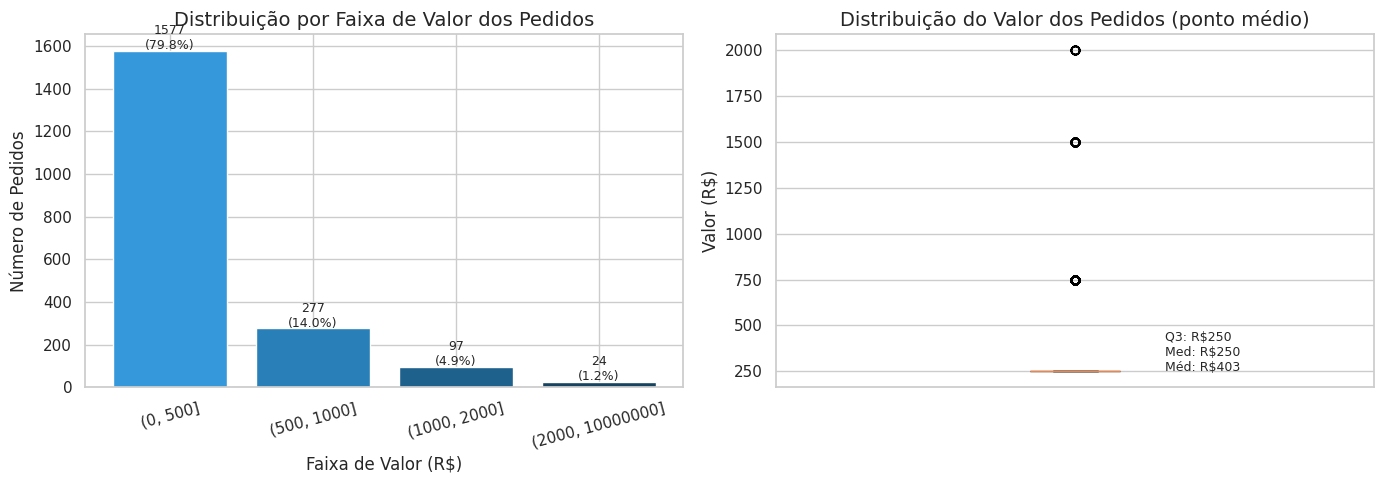

=== CORRELAÇÃO valor_num x atraso_num ===
Pearson: -0.0359

=== ATRASO MÉDIO POR FAIXA DE VALOR ===
                  mean  median  count
valor                                
(0, 500]          2.78     1.0   1577
(500, 1000]       2.83     1.0    277
(1000, 2000]      1.76     1.0     97
(2000, 10000000]  1.00     1.0     24


In [ ]:
# Seção 4 — Análise da Variável valor

# 4.1 — Estatísticas descritivas
print("=== ESTATÍSTICAS DE valor_num ===")
print(df_pedidos['valor_num'].describe().round(2))

# 4.2 — Distribuição por faixa
print("\n=== DISTRIBUIÇÃO POR FAIXA DE VALOR ===")
ordem_valor = ['(0, 500]', '(500, 1000]', '(1000, 2000]', '(2000, 10000000]']
dist_valor = df_pedidos['valor'].value_counts().reindex(ordem_valor)
dist_valor_pct = (dist_valor / len(df_pedidos) * 100).round(1)
print(pd.DataFrame({'count': dist_valor, 'pct': dist_valor_pct}))

# 4.3 — Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Distribuição por faixa de valor
cores_valor = ['#3498db', '#2980b9', '#1f618d', '#154360']
axes[0].bar(dist_valor.index, dist_valor.values, color=cores_valor, edgecolor='white')
axes[0].set_title('Distribuição por Faixa de Valor dos Pedidos')
axes[0].set_xlabel('Faixa de Valor (R$)')
axes[0].set_ylabel('Número de Pedidos')
axes[0].tick_params(axis='x', rotation=15)
for i, (v, p) in enumerate(zip(dist_valor.values, dist_valor_pct.values)):
    axes[0].text(i, v + 8, f'{v}\n({p}%)', ha='center', fontsize=9)

# Gráfico 2 — Boxplot do valor numérico
axes[1].boxplot(df_pedidos['valor_num'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Distribuição do Valor dos Pedidos (ponto médio)')
axes[1].set_ylabel('Valor (R$)')
axes[1].set_xticks([])
stats_valor = df_pedidos['valor_num'].describe()
axes[1].text(1.15, stats_valor['75%'],
             f"Q3: R${stats_valor['75%']:.0f}\n"
             f"Med: R${stats_valor['50%']:.0f}\n"
             f"Méd: R${stats_valor['mean']:.0f}",
             fontsize=9)
plt.tight_layout()
plt.show()

# 4.4 — Correlação entre valor e atraso
print("=== CORRELAÇÃO valor_num x atraso_num ===")
corr = df_pedidos['valor_num'].corr(df_pedidos['atraso_num'])
print(f"Pearson: {corr:.4f}")

# 4.5 — Atraso médio por faixa de valor
print("\n=== ATRASO MÉDIO POR FAIXA DE VALOR ===")
atraso_por_valor = (df_pedidos.groupby('valor')['atraso_num']
                   .agg(['mean', 'median', 'count'])
                   .reindex(ordem_valor)
                   .round(2))
print(atraso_por_valor)

### Interpretação

### 4.1 — Conversão para Ponto Médio

Assim como o `atraso`, a variável `valor` foi convertida para ponto médio
numérico. O intervalo `(2000, 10000000]` recebeu tratamento especial:
o limite superior de 10 milhões é um catch-all artificial, portanto foi
utilizado **R$2.000 como valor representativo** — o piso da faixa.

### 4.2 — Distribuição

A faixa `(0, 500]` domina absolutamente a distribuição, concentrando
**79,8% de todos os pedidos**. Isso se reflete diretamente nas estatísticas
descritivas: mediana e Q3 coincidem em 250 (ponto médio da faixa
dominante), enquanto a média de 403 é puxada pela cauda de pedidos maiores.
O boxplot é achatado pelo mesmo motivo observado no `atraso` — dominância
de uma única faixa categórica.

Esse perfil é consistente com o público da Praso: pequenos varejistas com
ciclo de compra de baixo volume e alta frequência.

### 4.3 — Relação entre Valor e Atraso

A correlação de Pearson entre valor e atraso é de **-0,036** — praticamente
nula — indicando que o valor do pedido, isoladamente, não explica o
comportamento de atraso. A mediana de atraso é 1,0 dia em todas as faixas,
reforçando que o atraso leve é um padrão universal independente do ticket.

Há uma leve tendência de queda no atraso médio conforme o valor aumenta
(de 2,78d para 1,0d), sugerindo que clientes com pedidos maiores podem ser
perfis mais estabelecidos financeiramente. Porém, as faixas de R$1.000+
possuem amostras pequenas (97 e 24 pedidos), o que limita conclusões
estatísticas robustas.

**Implicação para a modelagem:** o valor do pedido será útil principalmente
como indicador de perfil de consumo (ticket médio, valor máximo) e não como
preditor direto de atraso. Features derivadas como `valor_medio_cliente` e
`valor_maximo_cliente` capturam melhor o padrão de compra do que o valor
isolado de cada pedido.

## Seção 5 — Análise Comportamental por Cliente

Até aqui analisamos as variáveis a nível de pedido. Nesta seção, agregamos
o histórico de pedidos por cliente para explorar padrões comportamentais
e avaliar o poder preditivo das features candidatas antes de construí-las
definitivamente no pré-processamento.

O objetivo é responder: **o comportamento de compra e pagamento de um
cliente é um bom preditor de inadimplência?**

As agregações aqui são exploratórias — o dataset resultante não será salvo
para uso na modelagem.

In [ ]:
# Seção 5 — Análise Comportamental por Cliente

# 5.1 — Agregação exploratória por cliente
df_comp = df_pedidos.groupby('id_cliente').agg(
    contagem_pedidos    = ('id_pedido',   'count'),
    valor_medio         = ('valor_num',   'mean'),
    valor_maximo        = ('valor_num',   'max'),
    valor_total         = ('valor_num',   'sum'),
    atraso_medio        = ('atraso_num',  'mean'),
    atraso_mediano      = ('atraso_num',  'median'),
    atraso_maximo       = ('atraso_num',  'max'),
    atraso_total        = ('atraso_num',  'sum'),
    prop_pedidos_atrasados = ('atraso_num', lambda x: (x > 0).mean()),
    prop_atrasos_graves    = ('atraso_num', lambda x: (x > 6).mean()),
    tem_atraso_grave       = ('atraso_num', lambda x: int((x > 6).any())),
).reset_index()

# Merge com target
df_comp = df_comp.merge(
    df_app[['id_cliente', 'inadimplente']],
    on='id_cliente',
    how='left'
)

print(f"Clientes no dataset comportamental: {len(df_comp)}")
print(f"\nPrimeiras linhas:")
df_comp.head()

Clientes no dataset comportamental: 664

Primeiras linhas:


,id_cliente,contagem_pedidos,valor_medio,valor_maximo,valor_total,atraso_medio,atraso_mediano,atraso_maximo,atraso_total,prop_pedidos_atrasados,prop_atrasos_graves,tem_atraso_grave,inadimplente
0,1003899664289,3,250.000000,250.0,750.0,6.333333,8.0,8.0,19.0,1.000000,0.666667,1,0.0
1,1006479800959,3,250.000000,250.0,750.0,2.000000,1.0,5.0,6.0,0.666667,0.000000,0,0.0
2,1010025345946,3,416.666667,750.0,1250.0,1.000000,1.0,1.0,3.0,1.000000,0.000000,0,0.0
3,1012149504553,3,416.666667,750.0,1250.0,1.000000,1.0,1.0,3.0,1.000000,0.000000,0,0.0
4,1041056461533,3,416.666667,750.0,1250.0,1.333333,1.0,3.0,4.0,0.666667,0.000000,0,0.0


In [ ]:
# 5.2 — Estatísticas das features agregadas por grupo de inadimplência
features_comp = [
    'atraso_medio', 'atraso_mediano', 'atraso_maximo', 'atraso_total',
    'prop_pedidos_atrasados', 'prop_atrasos_graves',
    'valor_medio', 'valor_maximo', 'valor_total'
]

print("=== MÉDIAS POR GRUPO DE INADIMPLÊNCIA ===\n")
print(df_comp.groupby('inadimplente')[features_comp].mean().round(3).T)

=== MÉDIAS POR GRUPO DE INADIMPLÊNCIA ===

inadimplente                 0.0      1.0
atraso_medio               2.207    4.635
atraso_mediano             1.573    3.855
atraso_maximo              4.286    8.112
atraso_total               6.613   13.598
prop_pedidos_atrasados     0.692    0.856
prop_atrasos_graves        0.060    0.185
valor_medio              420.469  332.126
valor_maximo             566.540  402.174
valor_total             1259.506  963.768


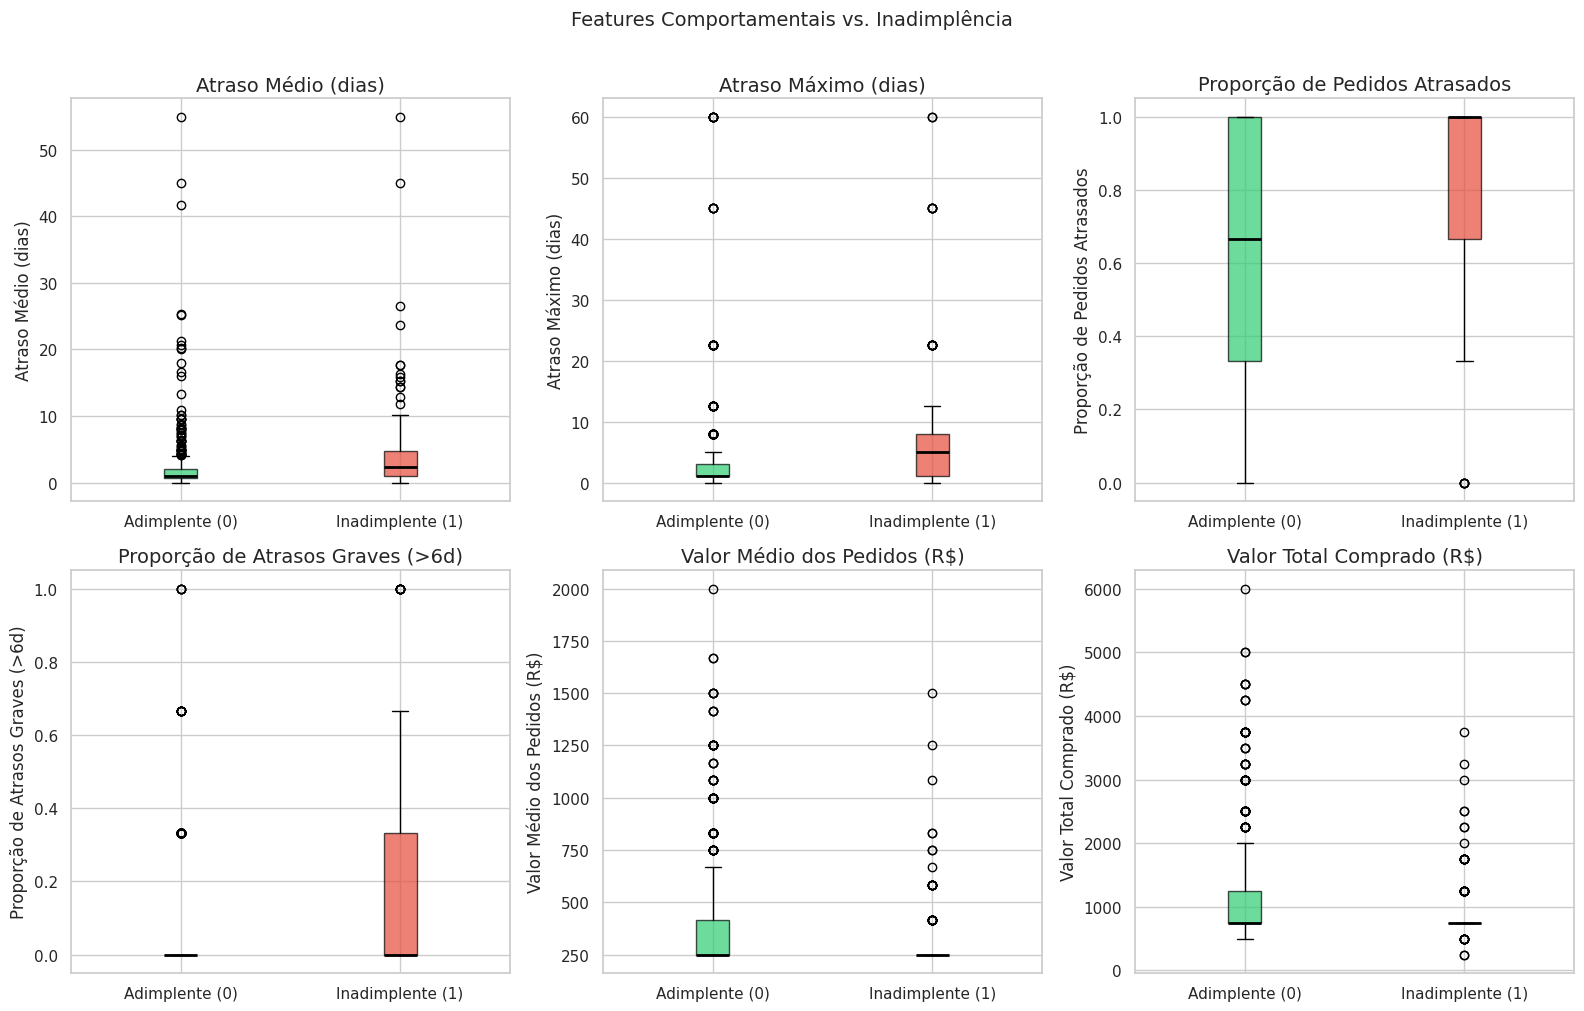

In [ ]:
# 5.3 — Visualização: features de atraso vs inadimplência
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_plot = [
    ('atraso_medio',           'Atraso Médio (dias)'),
    ('atraso_maximo',          'Atraso Máximo (dias)'),
    ('prop_pedidos_atrasados', 'Proporção de Pedidos Atrasados'),
    ('prop_atrasos_graves',    'Proporção de Atrasos Graves (>6d)'),
    ('valor_medio',            'Valor Médio dos Pedidos (R$)'),
    ('valor_total',            'Valor Total Comprado (R$)'),
]

for ax, (feat, label) in zip(axes, features_plot):
    grupos = [
        df_comp[df_comp['inadimplente'] == 0][feat].dropna(),
        df_comp[df_comp['inadimplente'] == 1][feat].dropna()
    ]
    ax.boxplot(grupos, labels=['Adimplente (0)', 'Inadimplente (1)'],
               patch_artist=True,
               boxprops=dict(alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.patches[0].set_facecolor('#2ecc71')
    ax.patches[1].set_facecolor('#e74c3c')
    ax.set_title(label)
    ax.set_ylabel(label)

plt.suptitle('Features Comportamentais vs. Inadimplência', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretação

### 5.1 — Agregação Exploratória

Para analisar o comportamento de pagamento a nível de cliente, os pedidos
foram agregados por `id_cliente`, gerando as seguintes features candidatas:

**Grupo 1 — Atraso:**
- `atraso_medio`, `atraso_mediano`, `atraso_maximo`, `atraso_total`
- `prop_pedidos_atrasados`: proporção de pedidos com atraso > 0
- `prop_atrasos_graves`: proporção de pedidos com atraso > 6 dias
- `tem_atraso_grave`: flag binária — cliente teve algum atraso > 6 dias

**Grupo 2 — Valor:**
- `valor_medio`, `valor_maximo`, `valor_total`

### 5.2 — Features de Atraso vs. Inadimplência

| Feature | Adimplente | Inadimplente | Diferença |
|:---|---:|---:|---:|
| Atraso médio (dias) | 2,21 | 4,64 | +2,43d |
| Atraso mediano (dias) | 1,57 | 3,86 | +2,29d |
| Atraso máximo (dias) | 4,29 | 8,11 | +3,82d |
| Atraso total (dias) | 6,61 | 13,60 | +6,99d |
| Prop. pedidos atrasados | 69,2% | 85,6% | +16,4pp |
| Prop. atrasos graves (>6d) | 6,0% | 18,5% | +12,5pp |

As features de atraso apresentam separação consistente entre os grupos,
porém com sobreposição considerável — refletida nos boxplots com outliers
extremos em ambos os lados.

O resultado mais contraintuitivo é o da **proporção de pedidos atrasados**:
adimplentes apresentam maior variância (caixa de 0,4 a 1,0) do que
inadimplentes (0,7 a 1,0). Isso revela que atrasar pedidos é um
comportamento generalizado na plataforma — adimplentes variam entre pagar
tudo em dia e atrasar sistematicamente, enquanto inadimplentes quase sempre
atrasam. O simples fato de atrasar, portanto, não discrimina bem o risco.

A feature com melhor separação visual é a **proporção de atrasos graves
(> 6 dias)**: a caixa dos adimplentes colapsa próxima de zero, enquanto
a dos inadimplentes é visivelmente mais ampla. Isso confirma a hipótese
levantada na Seção 3 — a fronteira real de risco começa a partir de
atrasos superiores a 6–7 dias.

### 5.3 — Features de Valor vs. Inadimplência

| Feature | Adimplente | Inadimplente |
|:---|---:|---:|
| Valor médio (Reais) | 420,47 | 332,13 |
| Valor máximo (Reais) | 566,54 | 402,17 |
| Valor total (Reais) | 1.259,51 | 963,77 |

A diferença entre os grupos é mais clara do que as médias sugerem.
No **valor médio**, a caixa dos inadimplentes está colapsada em R$250
— o ponto médio da faixa dominante `(0, 500]` — com menos outliers que os adimplentes,
indicando que a grande maioria dos inadimplentes compra exclusivamente
na faixa mais baixa. Adimplentes apresentam maior dispersão, com tickets
que alcançam faixas superiores.

No **valor total**, inadimplentes também ficam concentrados próximos de
750, com outliers que chegam até ~4.000. Adimplentes têm outliers
que ultrapassam 6.000 — reflexo de clientes com histórico de compras
de maior volume e maior comprometimento com a plataforma.

Esse padrão sugere que **clientes inadimplentes tendem a ser compradores
de baixo ticket que não evoluem para faixas maiores**, possivelmente por
já utilizarem o crédito de forma oportunista desde o início. As features
de valor, portanto, têm sinal preditivo relevante — não pelo valor
absoluto de cada pedido, mas pela **capacidade do cliente de comprar
acima da faixa mínima**.

## Seção 6 — Information Value (IV) das Features Comportamentais

O Information Value (IV) mede o poder preditivo de cada feature em relação
ao target, sendo amplamente utilizado em modelos de credit scoring. A mesma
escala utilizada na EDA de aplicação é aplicada aqui:

| IV | Poder Preditivo |
|:---|:---|
| < 0,02 | Inútil |
| 0,02 – 0,10 | Fraco |
| 0,10 – 0,30 | Médio |
| 0,30 – 0,50 | Forte |
| > 0,50 | Suspeitamente forte |

=== IV DAS FEATURES COMPORTAMENTAIS ===
               feature     iv classificacao
          atraso_medio 0.5098      Suspeito
          atraso_total 0.4594         Forte
        atraso_mediano 0.4356         Forte
         atraso_maximo 0.4179         Forte
prop_pedidos_atrasados 0.3514         Forte
           valor_total 0.1504         Médio
          valor_maximo 0.1408         Médio
           valor_medio 0.1369         Médio
   prop_atrasos_graves 0.0000        Inútil
      tem_atraso_grave 0.0000        Inútil


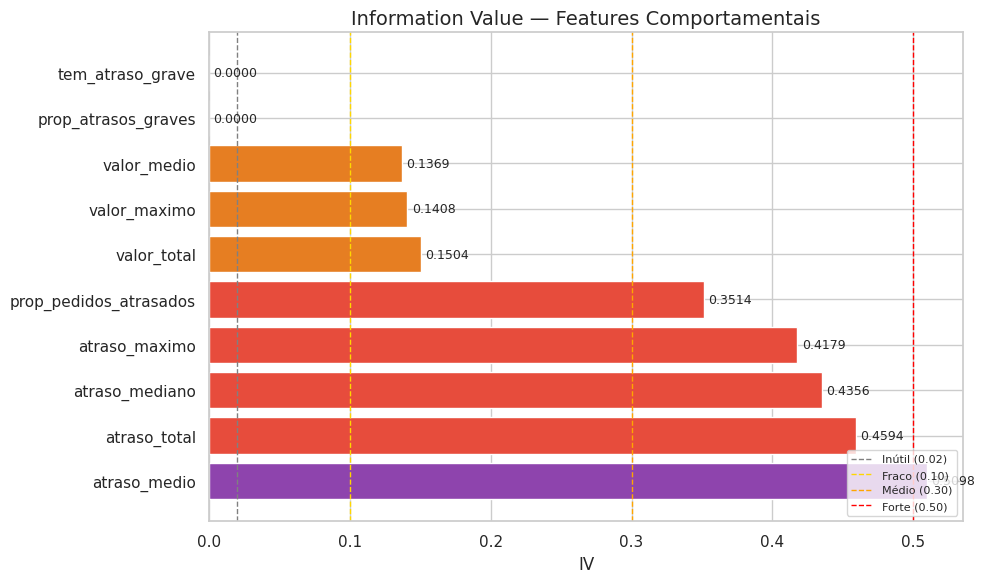

In [ ]:
# Seção 6 — IV das Features Comportamentais


def calcular_iv(df, feature, target='inadimplente', bins=5):
    """
    Calcula o Information Value de uma feature numérica contínua
    usando binning quantílico, ou categórica usando os valores únicos.
    """
    df_temp = df[[feature, target]].dropna().copy()

    # Binning quantílico para features contínuas
    try:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    except Exception:
        df_temp['bin'] = df_temp[feature]

    total_bons = (df_temp[target] == 0).sum()
    total_maus = (df_temp[target] == 1).sum()

    iv_total = 0
    tabela = []

    for bin_val, grupo in df_temp.groupby('bin', observed=True):
        bons = (grupo[target] == 0).sum()
        maus = (grupo[target] == 1).sum()

        p_bons = bons / total_bons if total_bons > 0 else 1e-10
        p_maus = maus / total_maus if total_maus > 0 else 1e-10

        # Evitar log(0)
        p_bons = max(p_bons, 1e-10)
        p_maus = max(p_maus, 1e-10)

        woe = np.log(p_bons / p_maus)
        iv  = (p_bons - p_maus) * woe
        iv_total += iv

        tabela.append({
            'bin': str(bin_val),
            'bons': bons, 'maus': maus,
            'p_bons': round(p_bons, 4),
            'p_maus': round(p_maus, 4),
            'woe': round(woe, 4),
            'iv': round(iv, 4)
        })

    return iv_total, pd.DataFrame(tabela)


# Features para calcular IV
features_iv = [
    'atraso_medio',
    'atraso_mediano',
    'atraso_maximo',
    'atraso_total',
    'prop_pedidos_atrasados',
    'prop_atrasos_graves',
    'tem_atraso_grave',
    'valor_medio',
    'valor_maximo',
    'valor_total',
]

# Calcular IV para cada feature
resultados_iv = []
for feat in features_iv:
    iv, _ = calcular_iv(df_comp, feat)
    resultados_iv.append({'feature': feat, 'iv': round(iv, 4)})

df_iv = (pd.DataFrame(resultados_iv)
           .sort_values('iv', ascending=False)
           .reset_index(drop=True))

def classificar_iv(iv):
    if iv < 0.02:   return 'Inútil'
    elif iv < 0.10: return 'Fraco'
    elif iv < 0.30: return 'Médio'
    elif iv < 0.50: return 'Forte'
    else:           return 'Suspeito'

df_iv['classificacao'] = df_iv['iv'].apply(classificar_iv)
print("=== IV DAS FEATURES COMPORTAMENTAIS ===")
print(df_iv.to_string(index=False))

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
cores_iv = df_iv['classificacao'].map({
    'Inútil': '#bdc3c7', 'Fraco': '#f1c40f',
    'Médio': '#e67e22',  'Forte': '#e74c3c',
    'Suspeito': '#8e44ad'
})
bars = ax.barh(df_iv['feature'], df_iv['iv'],
               color=cores_iv, edgecolor='white')
ax.axvline(0.02, color='gray',   linestyle='--', linewidth=1, label='Inútil (0.02)')
ax.axvline(0.10, color='gold',   linestyle='--', linewidth=1, label='Fraco (0.10)')
ax.axvline(0.30, color='orange', linestyle='--', linewidth=1, label='Médio (0.30)')
ax.axvline(0.50, color='red',    linestyle='--', linewidth=1, label='Forte (0.50)')
for bar, iv in zip(bars, df_iv['iv']):
    ax.text(iv + 0.003, bar.get_y() + bar.get_height()/2,
            f'{iv:.4f}', va='center', fontsize=9)
ax.set_title('Information Value — Features Comportamentais')
ax.set_xlabel('IV')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Investigar possível data leakage em atraso_medio
# Se o pedido que gerou inadimplência tem atraso muito alto,
# o atraso_medio do cliente seria inflado pelo próprio evento

print("=== DISTRIBUIÇÃO DE atraso_medio POR GRUPO ===")
print(df_comp.groupby('inadimplente')['atraso_medio'].describe().round(2))
print()

# Quantos clientes inadimplentes têm atraso_medio > 15 dias?
print("Inadimplentes com atraso_medio > 15d:",
      (df_comp[df_comp['inadimplente']==1]['atraso_medio'] > 15).sum())
print("Adimplentes com atraso_medio > 15d:",
      (df_comp[df_comp['inadimplente']==0]['atraso_medio'] > 15).sum())
print()

# Qual o atraso_medio máximo por grupo?
print("atraso_medio máximo — Inadimplente:",
      df_comp[df_comp['inadimplente']==1]['atraso_medio'].max())
print("atraso_medio máximo — Adimplente:",
      df_comp[df_comp['inadimplente']==0]['atraso_medio'].max())

=== DISTRIBUIÇÃO DE atraso_medio POR GRUPO ===
              count  mean   std  min   25%   50%   75%   max
inadimplente                                                
0.0           526.0  2.21  4.64  0.0  0.67  1.00  2.00  55.0
1.0           138.0  4.64  7.26  0.0  1.00  2.33  4.67  55.0

Inadimplentes com atraso_medio > 15d: 10
Adimplentes com atraso_medio > 15d: 12

atraso_medio máximo — Inadimplente: 55.0
atraso_medio máximo — Adimplente: 55.0


### Interpretação

### 6.1 — Ranking de IV

| Feature | IV | Classificação |
|:---|---:|:---|
| `atraso_medio` | 0,5098 | Suspeito* |
| `atraso_total` | 0,4594 | Forte |
| `atraso_mediano` | 0,4356 | Forte |
| `atraso_maximo` | 0,4179 | Forte |
| `prop_pedidos_atrasados` | 0,3514 | Forte |
| `valor_total` | 0,1504 | Médio |
| `valor_maximo` | 0,1408 | Médio |
| `valor_medio` | 0,1369 | Médio |
| `prop_atrasos_graves` | 0,0000 | Inútil |
| `tem_atraso_grave` | 0,0000 | Inútil |

*IV > 0,50 é classificado como "suspeito" por convenção, pois pode indicar
data leakage — o preditor capturando o próprio evento que tenta prever.

### 6.2 — Investigação de Data Leakage em `atraso_medio`

A classificação "suspeito" de `atraso_medio` (IV = 0,5098) motivou uma
investigação de possível data leakage. Os resultados descartam essa hipótese:

- Ambos os grupos atingem o mesmo atraso máximo (55 dias)
- Adimplentes com `atraso_medio` > 15 dias (n=12) superam inadimplentes (n=10)
- A separação ocorre na distribuição central: Q3 de adimplentes é 2,0 dias
  vs. 4,67 dias de inadimplentes — um sinal gradual e consistente, não
  uma separação artificial por valores extremos

O IV elevado de `atraso_medio` é, portanto, legítimo e reflete a capacidade
real dessa feature de ordenar clientes por risco de inadimplência.

### 6.3 — Interpretação dos Resultados

**Features de atraso dominam o ranking** com IVs entre 0,35 e 0,51 —
todas na faixa forte ou superior. Isso confirma que o comportamento de
pagamento dentro da plataforma é um sinal muito mais direto de risco do
que qualquer dado cadastral externo. Para referência, a feature mais forte
da EDA de aplicação foi `idade_cnpj` com IV de 0,3651 — já superada por
quatro features comportamentais.

**Features de valor apresentam poder preditivo médio** (IV entre 0,13 e
0,15), consistente com a análise bivariada: clientes inadimplentes tendem
a comprar em tickets menores e não evoluem para faixas de valor superiores.

**`prop_atrasos_graves` e `tem_atraso_grave` apresentaram IV nulo** —
resultado aparentemente contraditório, explicado pela limitação estrutural
do dataset: com apenas 3 pedidos por cliente, a grande maioria dos clientes
possui 0 pedidos graves, tornando a variância dessas features insuficiente
para o binning quantílico discriminar os grupos. Essas features serão
mantidas como candidatas no pré-processamento, onde poderão ser avaliadas
diretamente pelos modelos sem depender de binning.

### 6.4 — Comparação com Features de Aplicação

| Origem | Feature | IV | Classificação |
|:---|:---|---:|:---|
| Comportamental | `atraso_medio` | 0,5098 | Suspeito* |
| Comportamental | `atraso_total` | 0,4594 | Forte |
| Comportamental | `atraso_mediano` | 0,4356 | Forte |
| Comportamental | `atraso_maximo` | 0,4179 | Forte |
| Comportamental | `prop_pedidos_atrasados` | 0,3514 | Forte |
| Aplicação | `idade_cnpj` | 0,3651 | Forte |
| Comportamental | `valor_total` | 0,1504 | Médio |
| Aplicação | `serasa_socio_negativado` | 0,2053 | Médio |
| Aplicação | `segmento_cliente` | 0,1978 | Médio |
| Aplicação | `qtd_credores` | 0,1694 | Médio |

O modelo comportamental tem acesso a sinais substancialmente mais fortes
do que o modelo de aplicação. Isso é esperado — dados comportamentais
dentro da plataforma capturam o risco de forma direta, enquanto dados
cadastrais externos são proxies indiretos do perfil do cliente.

## Seção 7 — Insights, Decisões e Plano para o Pré-processamento

Esta seção consolida os principais achados da EDA comportamental e traduz
cada um em decisões concretas para o notebook `04_preprocessing.ipynb`.

---

### 7.1 — Principais Achados

**Sobre a estrutura do dataset:**
- 1.977 pedidos pertencentes a 664 clientes únicos
- Apenas 22,1% dos clientes cadastrados realizaram compras — o modelo
  comportamental será aplicado exclusivamente a esse subconjunto
- Praticamente todos os clientes possuem exatamente 3 pedidos (mediana=3,
  std=0,17) — indício de corte intencional na exportação dos dados
- Cobertura temporal de ~4 anos (abr/2022 – abr/2026)
- Integridade referencial garantida: todos os pedidos pertencem a clientes
  cadastrados

**Sobre o comportamento de atraso:**
- 72,5% dos pedidos atrasam alguma coisa — atrasar é o comportamento padrão
- 45,7% dos pedidos atrasam apenas 1–2 dias — atraso leve é provavelmente
  operacional (fins de semana, processamento bancário), não financeiro
- A fronteira real de risco começa em ~7 dias de atraso
- Apenas 2,8% dos pedidos têm atraso grave (>15 dias), mas concentram
  o sinal preditivo do modelo

**Sobre o comportamento de valor:**
- 79,8% dos pedidos estão na faixa até 500 — público de baixo ticket
- Clientes inadimplentes ficam concentrados na faixa mínima (250) e
  raramente evoluem para faixas superiores
- Adimplentes apresentam dispersão maior e atingem volumes totais
  superiores a R$6.000

**Sobre o poder preditivo (IV):**
- **Suspeito (>0,50):** `atraso_medio` (0,5098) — investigado, sem
  evidência de leakage
- **Forte (0,30–0,50):** `atraso_total` (0,4594), `atraso_mediano` (0,4356),
  `atraso_maximo` (0,4179), `prop_pedidos_atrasados` (0,3514)
- **Médio (0,10–0,30):** `valor_total` (0,1504), `valor_maximo` (0,1408),
  `valor_medio` (0,1369)
- **Inútil:** `prop_atrasos_graves`, `tem_atraso_grave` — limitação
  estrutural do binning quantílico com apenas 3 pedidos por cliente

**Sobre a comparação com o modelo de aplicação:**
- 4 features comportamentais superam a feature mais forte do aplicação
  (`idade_cnpj`, IV=0,3651)
- O modelo comportamental terá acesso a sinais substancialmente mais
  fortes — esperamos ROC-AUC superior ao modelo de aplicação

---

### 7.2 — Decisões para o Pré-processamento

#### Filtragem de Clientes
- O dataset de modelagem incluirá apenas os 664 clientes com histórico
  de pedidos
- Os 2.336 clientes sem pedidos permanecem cobertos pelo modelo de aplicação

#### Remoção de Registros
- Remover os 2 pedidos com missing em `valor` ou `atraso` (0,10% da base)
- Decisão justificada pelo volume irrisório e impossibilidade de imputação
  segura

#### Conversão de Intervalos para Ponto Médio
Aplicar a função `intervalo_para_ponto_medio` com tratamentos especiais:

**Para `atraso`:**
- `(-100, 0]` → **0** (sem atraso real)
- `(60, 10000000]` → **60** (catch-all conservador)

**Para `valor`:**
- `(2000, 10000000]` → **2000** (catch-all conservador)

#### Conversão de Tipos
- `data_entrega`: converter de string para `datetime`

#### Geração de Features Agregadas por Cliente

**Grupo 1 — Atraso (alta prioridade):**
- `atraso_medio`, `atraso_mediano`, `atraso_maximo`, `atraso_total`
- `prop_pedidos_atrasados`

**Grupo 2 — Valor (média prioridade):**
- `valor_medio`, `valor_maximo`, `valor_total`

**Grupo 3 — Volume (baixa prioridade, baixa variância):**
- `contagem_pedidos` — pouco discriminante dado que ~100% dos clientes
  têm 3 pedidos, mas mantida para tratar os 2 clientes com 1 pedido

**Grupo 4 — Recência (a explorar no preprocessing):**
- `dias_desde_ultimo_pedido` — pode capturar afastamento da plataforma
- `dias_desde_primeiro_pedido` — antiguidade como cliente

#### Features Candidatas a Avaliação Direta nos Modelos
- `prop_atrasos_graves` e `tem_atraso_grave` apresentaram IV nulo no
  binning quantílico, mas serão mantidas como features candidatas. Modelos
  baseados em árvores podem capturar valor preditivo sem depender de
  binning, especialmente em combinação com outras features

#### Merge com Dataset de Aplicação
- JOIN do tipo `LEFT` partindo do dataset comportamental: `df_comportamental
  LEFT JOIN df_aplicacao_processado ON id_cliente`
- Garantia: nenhum cliente perdido, todos os 664 estão no aplicação
- Output: dataset único com features cadastrais + comportamentais

#### Multicolinearidade entre Features de Atraso
- As 4 features de atraso (medio, mediano, maximo, total) provavelmente
  apresentarão correlação alta entre si — investigar no preprocessing
- Para modelos lineares: avaliar redução para 1-2 features
- Para modelos de árvore (XGBoost, Random Forest): manter todas, a
  redundância não prejudica

---

### 7.3 — Divisão Treino/Teste — Cuidados Críticos

O dataset comportamental tem apenas **664 clientes**, com 138 inadimplentes
(20,8%). Esse volume reduzido impõe cuidados adicionais:

1. **Estratificação obrigatória** pelo target dado o desbalanceamento
2. **Validação cruzada** com k-fold estratificado em vez de uma única
   divisão treino/teste — maximiza o uso dos dados disponíveis
3. **Todas as transformações** (cálculos de estatísticas, encoding,
   imputação) devem ser realizadas dentro de cada fold para evitar leakage
4. **Sugestão de divisão:** 5-fold stratified cross-validation, com hold-out
   final de 15% para teste
